#  Setpoint Prediction — Data Loader 


---

### Notebook Sections
1. Setup & Imports
2. Loading the Dataset
3. Exploratory Data Analysis (EDA)


---
## 1. Setup & Imports

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch_geometric.data import Data, InMemoryDataset
from torch_geometric.loader import DataLoader

# ── Paths ─────────────────────────────────────────────────────────────────
NOTEBOOK_DIR  = Path().resolve()
PROJECT_ROOT  = NOTEBOOK_DIR.parents[2]          # gnn_drone_project/
DATASETS_DIR  = PROJECT_ROOT / "datasets"
SRC_DIR       = NOTEBOOK_DIR.parent / "src"
RESULTS_DIR   = NOTEBOOK_DIR.parent / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

DATASET_NAME  = "setpoint_mixed_v1_mixed_formations"

TRAIN_PATH = DATASETS_DIR / f"{DATASET_NAME}_train.pt"
VAL_PATH   = DATASETS_DIR / f"{DATASET_NAME}_val.pt"
TEST_PATH  = DATASETS_DIR / f"{DATASET_NAME}_test.pt"
META_PATH  = DATASETS_DIR / f"{DATASET_NAME}_metadata.json"

for p in [TRAIN_PATH, VAL_PATH, TEST_PATH, META_PATH]:
    status = "✅" if p.exists() else "❌ MISSING"
    print(f"  {status}  {p.name}")

print(f"\nPyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")

c:\Users\aimen\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  ✅  setpoint_mixed_v1_mixed_formations_train.pt
  ✅  setpoint_mixed_v1_mixed_formations_val.pt
  ✅  setpoint_mixed_v1_mixed_formations_test.pt
  ✅  setpoint_mixed_v1_mixed_formations_metadata.json

PyTorch version : 2.7.1+cu118
CUDA available  : True


---
## 2. Loading the Dataset

In [ ]:
class DroneSwarmDataset(InMemoryDataset):
    """
    Loader for pre-built .pt split files from datacollection.py.

    Stored fields per Data graph:
      x            [N, 25]  – Raw node features (velocities + obstacles + formation)
      target       [N, 4]   – Expert setpoint error [Δx, Δy, Δz, Δyaw] → YOUR LABEL
      y            [N, 4]   – Motor PWM (NOT used — PID handles this)
      edge_index   [2, E]   – Directed communication graph
      edge_attr    [E, 3]   – Relative 3D position (pⱼ - pᵢ)
      pos          [N, 3]   – World-frame position (visualization only)
      formation_id [1]      – 0=A, 1=rectangle, 2=triangle
      episode_id   [1]
      step_idx     [1]
      num_drones   [1]
    """

    def __init__(self, split_path: str | Path):
        split_path = Path(split_path)
        if not split_path.exists():
            raise FileNotFoundError(f"Dataset file not found: {split_path}")

        payload = torch.load(split_path, weights_only=False)

        self.formation_names = payload.get("formation_names", ["a", "rectangle", "triangle"])
        self.split_name      = payload.get("split_name", "unknown")

        super().__init__(root="")

        self.data   = payload["data"]
        self.slices = payload["slices"]


# ── Load all three splits ──────────────────────────────────────────────────
print("Loading datasets...")
train_ds = DroneSwarmDataset(TRAIN_PATH)
val_ds   = DroneSwarmDataset(VAL_PATH)
test_ds  = DroneSwarmDataset(TEST_PATH)

print(f"\n{'Split':<10} {'Graphs':>8}")
for name, ds in [("train", train_ds), ("val", val_ds), ("test", test_ds)]:
    print(f"{name:<10} {len(ds):>8,}")

Loading datasets...

Split        Graphs
----------------------
train        48,013
val           6,099
test          6,362


In [ ]:
# ── Inspect one sample graph ──────────────────────────────────────────────
g = train_ds[0]


print(f"SAMPLE GRAPH — episode {int(g.episode_id)} | step {int(g.step_idx)}")
print(f"  Num drones (nodes)  : {int(g.num_drones)}")
print(f"  Formation           : {train_ds.formation_names[int(g.formation_id)]}")
print(f"  x (raw state)       : {tuple(g.x.shape)}   (25-dim raw, will become 9)")
print(f"  target (setpoint)   : {tuple(g.target.shape)}   ← YOUR LABEL")
print(f"  y (PWM — not used)  : {tuple(g.y.shape)}")
print(f"  edge_index          : {tuple(g.edge_index.shape)}")
print(f"  edge_attr           : {tuple(g.edge_attr.shape)}   (will become 4 with distance)")
print(f"  pos (world 3D)      : {tuple(g.pos.shape)}")
print()
print("Drone 0:")
print(f"  velocities     : {g.x[0, :6].numpy().round(4)}")
print(f"  formation      : {g.x[0, 22:].numpy().round(4)}")
print(f"  expert setpoint: {g.target[0].numpy().round(4)}  [Δx, Δy, Δz, Δyaw] ← LABEL")

SAMPLE GRAPH — episode 0 | step 0
  Num drones (nodes)  : 17
  Formation           : a
  x (raw state)       : (17, 25)   (25-dim raw, will become 9)
  target (setpoint)   : (17, 4)   ← YOUR LABEL
  y (PWM — not used)  : (17, 4)
  edge_index          : (2, 128)
  edge_attr           : (128, 3)   (will become 4 with distance)
  pos (world 3D)      : (17, 3)

Drone 0:
  velocities     : [0. 0. 0. 0. 0. 0.]
  formation      : [1. 0. 0.]
  expert setpoint: [ 4.5891  4.2884 -1.128   2.0098]  [Δx, Δy, Δz, Δyaw] ← LABEL


---
## 3. Exploratory Data Analysis (EDA)

### 3.1 Feature Map

```
x[:, 0:3]   — Local linear velocity  (vx, vy, vz)      KEEP   z-score
x[:, 3:6]   — Local angular velocity (ωx, ωy, ωz)      KEEP   z-score
x[:, 6:22]  — Obstacle distances     (16 placeholder)   DROP   constant=5.0
x[:, 22:25] — Formation one-hot      [A, rect, tri]     KEEP   pass-through {0,1}
```

### Input (9-dim):

| Idx | Source | Name | Normalization |
|-----|--------|------|---------------|
| 0 | `x[:,0]` | `vel_x` | Z-score |
| 1 | `x[:,1]` | `vel_y` | Z-score |
| 2 | `x[:,2]` | `vel_z` | Z-score |
| 3 | `x[:,3]` | `ang_x` | Z-score |
| 4 | `x[:,4]` | `ang_y` | Z-score |
| 5 | `x[:,5]` | `ang_z` | Z-score |
| 6 | `x[:,22]` | `form_a` | NONE {0,1} |
| 7 | `x[:,23]` | `form_rect` | NONE {0,1} |
| 8 | `x[:,24]` | `form_tri` | NONE {0,1} |

### Label (4-dim) — Z-score normalized:

| Idx | Source | Name | Unit | Normalization |
|-----|--------|------|------|---------------|
| 0 | `target[:,0]` | `Δx` | metres | Z-score |
| 1 | `target[:,1]` | `Δy` | metres | Z-score |
| 2 | `target[:,2]` | `Δz` | metres | Z-score |
| 3 | `target[:,3]` | `Δyaw` | radians | Z-score |

### Edge features (4-dim):

| Idx | Name | Description |
|-----|------|-------------|
| 0 | `rel_x` | Relative X position |
| 1 | `rel_y` | Relative Y position |
| 2 | `rel_z` | Relative Z position |
| 3 | `distance` | √(x²+y²+z²) — helps attention learn distance gating |

In [10]:
# Verify obstacle columns are constant 
all_x_raw = train_ds._data.x

obs_std = all_x_raw[:, 6:22].std(dim=0)
print("Obstacle columns (indices 6-21) std:")
print(obs_std.numpy())

Obstacle columns (indices 6-21) std:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [5]:
# ── Names and indices ──────────────────────────────────────────────────────
X_KEEP_INDICES = [0, 1, 2, 3, 4, 5, 22, 23, 24]

INPUT_NAMES = [
    "vel_x", "vel_y", "vel_z",
    "ang_x", "ang_y", "ang_z",
    "form_a", "form_rect", "form_tri",
]
LABEL_NAMES = ["Δx", "Δy", "Δz", "Δyaw"]
EDGE_NAMES  = ["rel_x", "rel_y", "rel_z", "distance"]

print(f"Input:  {len(INPUT_NAMES)} dims  (local state — what the drone senses)")
for i, name in enumerate(INPUT_NAMES):
    norm = "pass-through" if i >= 6 else "z-score"
    print(f"   [{i}]  {name:<12} ({norm})")

print(f"\nLabel:  {len(LABEL_NAMES)} dims  (expert setpoint — what to predict)")
for i, name in enumerate(LABEL_NAMES):
    print(f"   [{i}]  {name:<12} (z-score)")

print(f"\nEdge:   {len(EDGE_NAMES)} dims")

Input:  9 dims  (local state — what the drone senses)
   [0]  vel_x        (z-score)
   [1]  vel_y        (z-score)
   [2]  vel_z        (z-score)
   [3]  ang_x        (z-score)
   [4]  ang_y        (z-score)
   [5]  ang_z        (z-score)
   [6]  form_a       (pass-through)
   [7]  form_rect    (pass-through)
   [8]  form_tri     (pass-through)

Label:  4 dims  (expert setpoint — what to predict)
   [0]  Δx           (z-score)
   [1]  Δy           (z-score)
   [2]  Δz           (z-score)
   [3]  Δyaw         (z-score)

Edge:   4 dims


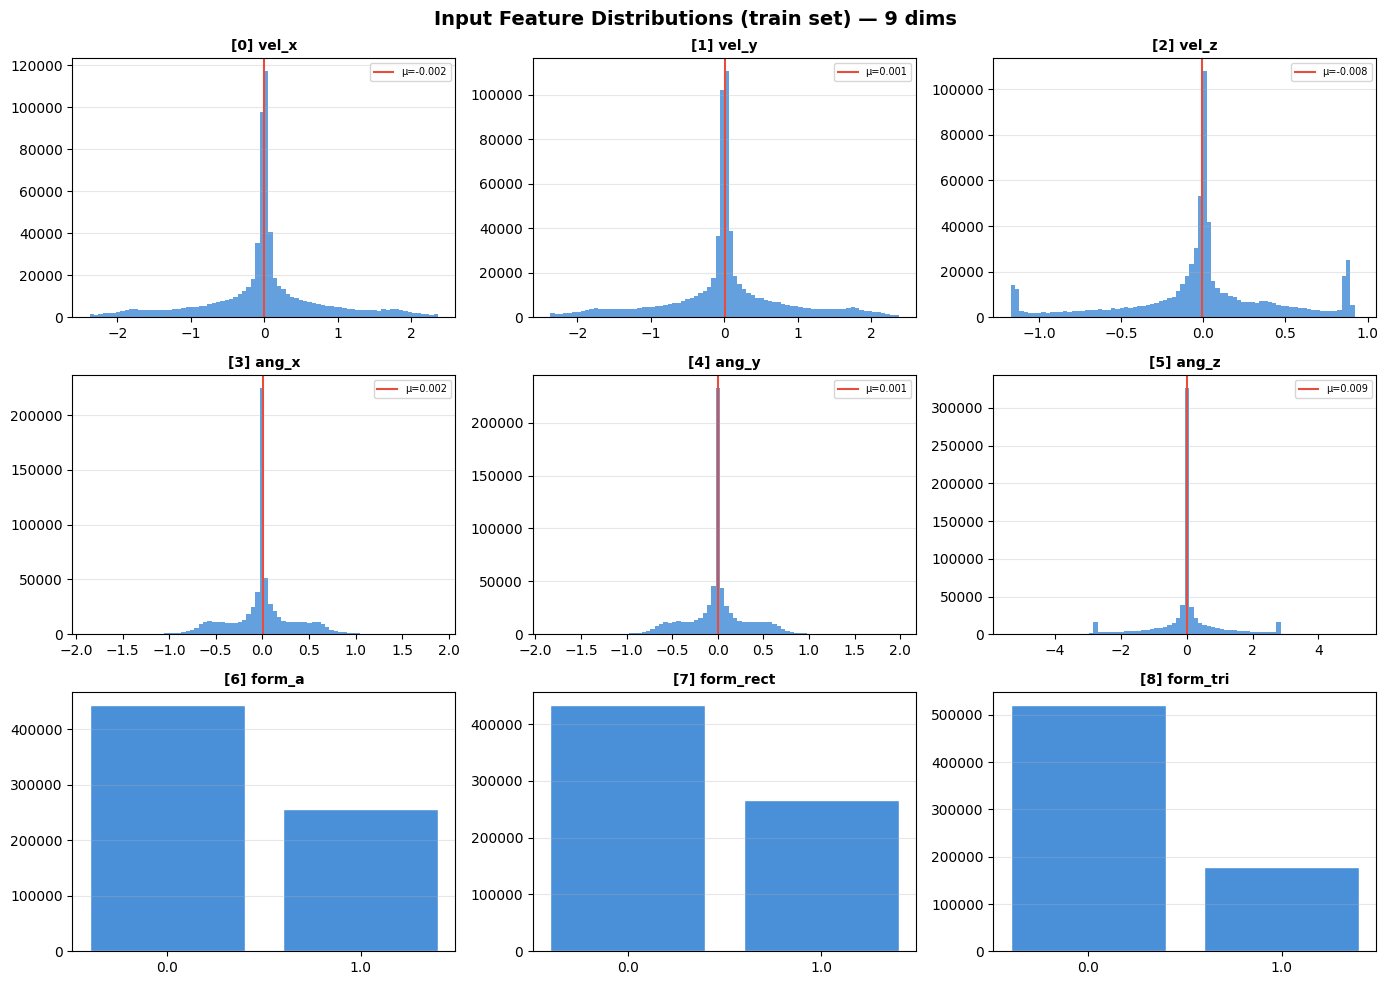

In [6]:
# ── 3.2  Distribution of INPUT features ───────────────────────────────────
x_kept = all_x_raw[:, X_KEEP_INDICES].numpy()

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
fig.suptitle("Input Feature Distributions (train set) — 9 dims",
             fontsize=14, fontweight="bold")

for i, (ax, name) in enumerate(zip(axes.flat, INPUT_NAMES)):
    col = x_kept[:, i]
    if name.startswith("form"):
        unique, counts = np.unique(col, return_counts=True)
        ax.bar(unique.astype(str), counts, color="#4a90d9", edgecolor="white")
    else:
        ax.hist(col, bins=80, color="#4a90d9", edgecolor="none", alpha=0.85)
        ax.axvline(col.mean(), color="#e74c3c", lw=1.5,
                   label=f"μ={col.mean():.3f}")
        ax.legend(fontsize=7)
    ax.set_title(f"[{i}] {name}", fontweight="bold", fontsize=10)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "input_feature_distributions.png", dpi=120)
plt.show()

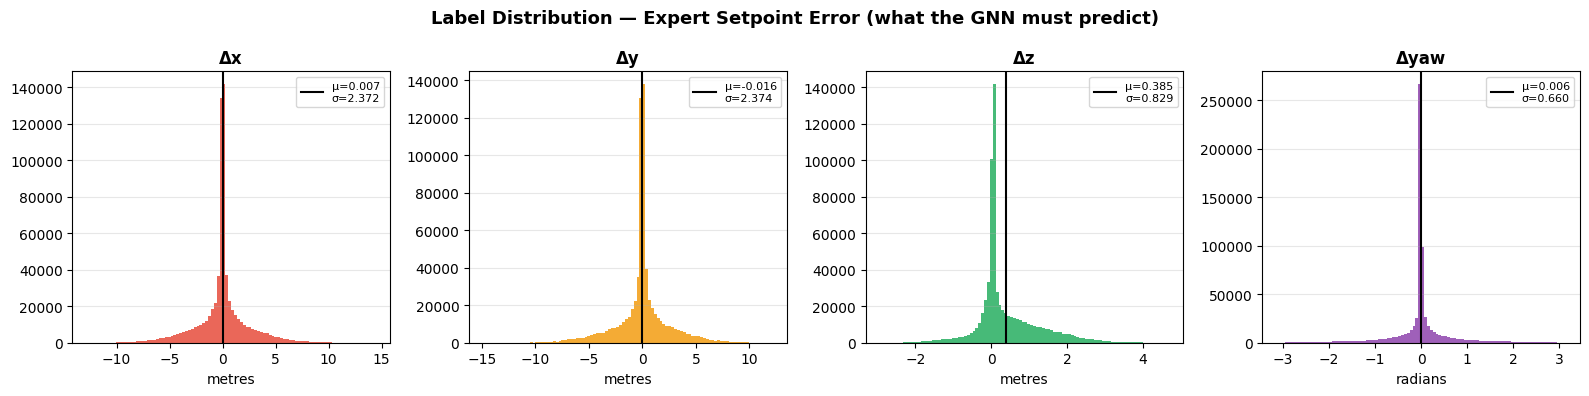

Setpoint label stats:
  mean : [ 0.0069 -0.0157  0.3846  0.0056]
  std  : [2.3712 2.3725 0.8293 0.66  ]
  min  : [-12.8041 -14.8606  -2.9316  -3.1398]
  max  : [14.4332 12.144   4.679   3.1409]

  Large ranges (up to ±15m) → Z-score normalization is MANDATORY


In [11]:
# ── 3.3  Distribution of LABEL (expert setpoints) ─────────────────────────
all_target = train_ds._data.target.numpy()

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Label Distribution — Expert Setpoint Error (what the GNN must predict)",
             fontsize=13, fontweight="bold")

colors = ["#e74c3c", "#f39c12", "#27ae60", "#8e44ad"]
units  = ["metres", "metres", "metres", "radians"]
for i, (ax, name, color, unit) in enumerate(zip(axes, LABEL_NAMES, colors, units)):
    col = all_target[:, i]
    ax.hist(col, bins=100, color=color, edgecolor="none", alpha=0.85)
    ax.axvline(col.mean(), color="black", lw=1.5,
               label=f"μ={col.mean():.3f}\nσ={col.std():.3f}")
    ax.set_title(f"{name}", fontweight="bold")
    ax.set_xlabel(unit)
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "label_setpoint_distributions.png", dpi=120)
plt.show()

print(f"Setpoint label stats:")
print(f"  mean : {all_target.mean(0).round(4)}")
print(f"  std  : {all_target.std(0).round(4)}")
print(f"  min  : {all_target.min(0).round(4)}")
print(f"  max  : {all_target.max(0).round(4)}")
print(f"\n  Large ranges (up to ±15m) → Z-score normalization is MANDATORY")

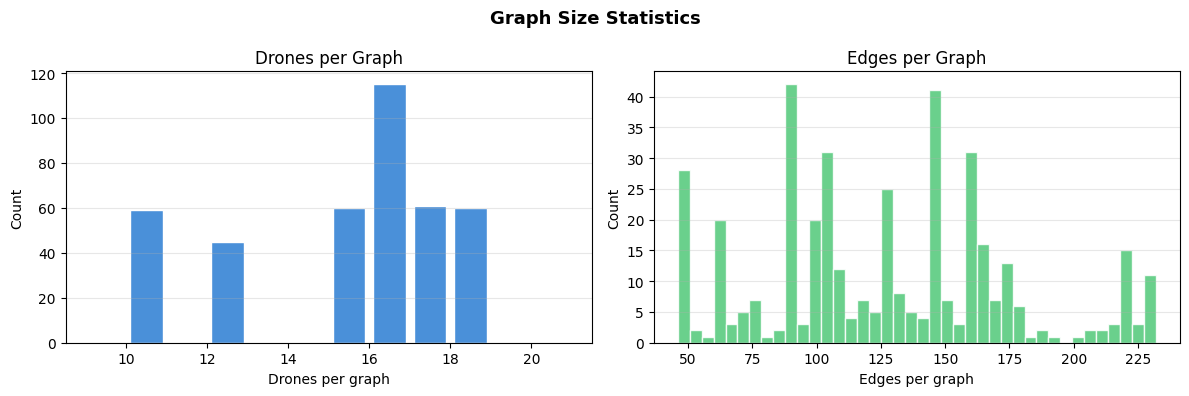

Drones/graph: min=10, max=18, mean=15.0
Edges/graph:  min=46, max=232, mean=126.6


In [8]:
# ── 3.4  Graph size stats ──────────────────────────────────────────────────
num_drones_list, num_edges_list = [], []

for i in range(0, min(len(train_ds), 2000), 5):
    g = train_ds[i]
    num_drones_list.append(int(g.num_drones))
    num_edges_list.append(g.edge_index.shape[1])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Graph Size Statistics", fontsize=13, fontweight="bold")

ax1.hist(num_drones_list, bins=range(9, 22), color="#4a90d9",
         edgecolor="white", rwidth=0.8)
ax1.set_xlabel("Drones per graph"); ax1.set_ylabel("Count")
ax1.set_title("Drones per Graph")

ax2.hist(num_edges_list, bins=40, color="#50c878", edgecolor="white", alpha=0.85)
ax2.set_xlabel("Edges per graph"); ax2.set_ylabel("Count")
ax2.set_title("Edges per Graph")

for ax in [ax1, ax2]: ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "graph_size_stats.png", dpi=120)
plt.show()

print(f"Drones/graph: min={min(num_drones_list)}, max={max(num_drones_list)}, "
      f"mean={np.mean(num_drones_list):.1f}")
print(f"Edges/graph:  min={min(num_edges_list)}, max={max(num_edges_list)}, "
      f"mean={np.mean(num_edges_list):.1f}")

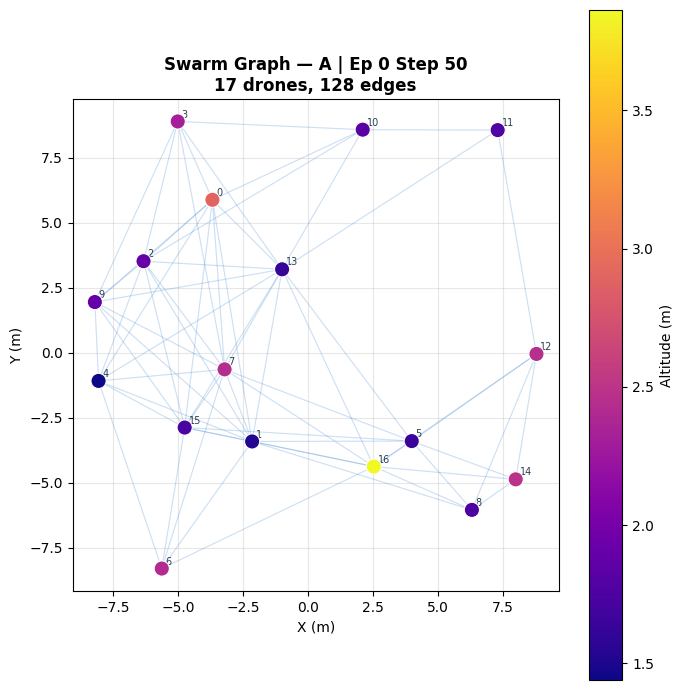

In [9]:
# ── 3.5  Visualise one swarm graph ─────────────────────────────────────────
sample_idx = 50
g = train_ds[sample_idx]
formation_label = train_ds.formation_names[int(g.formation_id)]
pos_np = g.pos.numpy()
ei = g.edge_index.numpy()

fig, ax = plt.subplots(figsize=(7, 7))
for src, dst in zip(ei[0], ei[1]):
    ax.plot([pos_np[src, 0], pos_np[dst, 0]],
            [pos_np[src, 1], pos_np[dst, 1]],
            color="#4a90d9", alpha=0.15, lw=0.8)

sc = ax.scatter(pos_np[:, 0], pos_np[:, 1], c=pos_np[:, 2], cmap="plasma",
                s=120, zorder=5, edgecolors="white", lw=0.8)
plt.colorbar(sc, ax=ax, label="Altitude (m)")
for i, (x, y) in enumerate(pos_np[:, :2]):
    ax.text(x + 0.15, y + 0.15, str(i), fontsize=7, color="#2c3e50")

ax.set_xlabel("X (m)"); ax.set_ylabel("Y (m)")
ax.set_title(f"Swarm Graph — {formation_label.upper()} | "
             f"Ep {int(g.episode_id)} Step {int(g.step_idx)}\n"
             f"{int(g.num_drones)} drones, {ei.shape[1]} edges", fontweight="bold")
ax.set_aspect("equal"); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "swarm_graph_snapshot.png", dpi=120)
plt.show()